# Venn Diagram Gallery

Venn diagrams visualise relationships between two or three sets, surfacing both unique members and shared overlaps. They work well for retail questions where a single customer or product can belong to several segments at once: who shops both online and in-store, which categories share buyers, where two campaigns reach the same audience.

Venn diagrams excel at:
- **Set relationships**: see how customer or product groups intersect at a glance
- **Overlap analysis**: quantify the share of the audience reached by two channels at the same time
- **Cross-category buying**: surface how often customers shop across multiple categories
- **Audience deduplication**: avoid double-counting when sizing combined campaigns or segments

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import venn

## Two-Set Venn Diagram

Pass two `labels` and a DataFrame whose `groups` column holds two-element tuples (one tuple per region of the diagram, including the outside region `(0, 0)`). The `percent` column carries the share of the population in each region. Two-set is the simplest shape and the easiest to read at a glance.

Region tuples use 1 for membership and 0 for non-membership: `(1, 0)` is the first set only, `(1, 1)` is the overlap, `(0, 0)` is everyone in neither set. The `(0, 0)` row is allowed but is not drawn — it is useful to keep around so the percentages sum to 100 for documentation.

---

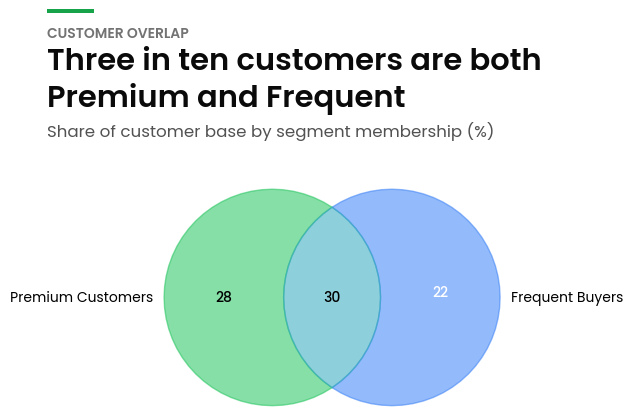

In [ ]:
# Premium customers vs Frequent buyers. ~30% are both.
two_set_data = pd.DataFrame(
    {
        "groups": [(1, 0), (0, 1), (1, 1), (0, 0)],
        "percent": [28, 22, 30, 20],
    },
)

venn.plot(
    two_set_data,
    labels=["Premium Customers", "Frequent Buyers"],
    eyebrow="Customer overlap",
    title="Three in ten customers are both Premium and Frequent",
    subtitle="Share of customer base by segment membership (%)",
)
plt.show()

## Three-Set Venn Diagram

Pass three `labels` and use three-element tuples in the `groups` column. The diagram now has seven visible regions: three exclusive ones, three pairwise overlaps, and one triple overlap in the middle. Add `(0, 0, 0)` for the share belonging to none of the three sets if you want the percentages to sum cleanly.

Three-set diagrams are noticeably busier than two-set ones, so save them for cases where the central triple overlap or the pairwise overlaps are themselves part of the story.

---

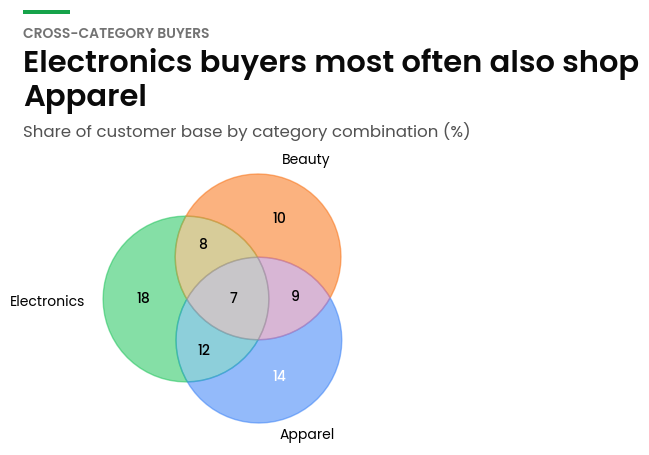

In [ ]:
# Cross-category buyers across Electronics, Apparel, Beauty.
# 7% buy across all three; Electronics + Apparel is the largest pairwise overlap.
three_set_data = pd.DataFrame(
    {
        "groups": [
            (1, 0, 0),
            (0, 1, 0),
            (0, 0, 1),  # exclusive to one category
            (1, 1, 0),
            (1, 0, 1),
            (0, 1, 1),  # two-category overlap
            (1, 1, 1),
            (0, 0, 0),  # all three / none
        ],
        "percent": [18, 14, 10, 12, 8, 9, 7, 22],
    },
)

venn.plot(
    three_set_data,
    labels=["Electronics", "Apparel", "Beauty"],
    eyebrow="Cross-category buyers",
    title="Electronics buyers most often also shop Apparel",
    subtitle="Share of customer base by category combination (%)",
)
plt.show()

## Euler Diagram Mode

Set `vary_size=True` to switch from a Venn (fixed-size circles) to an Euler diagram, where each circle's area is proportional to the size of its set. Use this when the relative sizes of the sets are themselves the story — for example when one channel reaches a much larger audience than another.

Euler diagrams can omit empty regions entirely: if two sets do not overlap in the data, their circles will not touch. This makes them more honest than Venn diagrams, but trickier to lay out cleanly when the proportions are unusual.

---

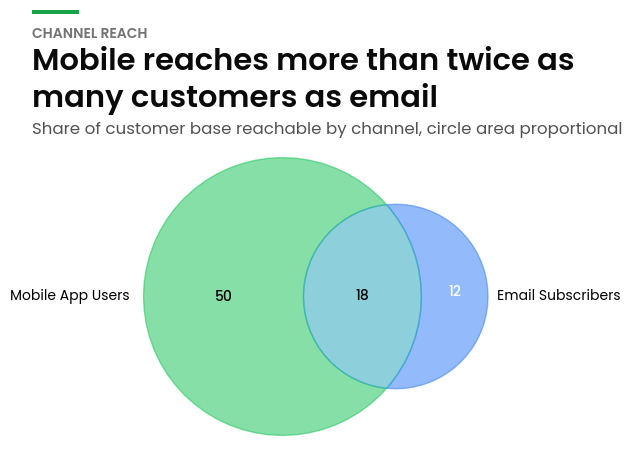

In [ ]:
# Mobile users dominate; email is a much smaller circle.
# Mobile reach total = 50 + 18 = 68; Email reach total = 12 + 18 = 30.
channel_reach_data = pd.DataFrame(
    {
        "groups": [(1, 0), (0, 1), (1, 1), (0, 0)],
        "percent": [50, 12, 18, 20],
    },
)

venn.plot(
    channel_reach_data,
    labels=["Mobile App Users", "Email Subscribers"],
    vary_size=True,
    eyebrow="Channel reach",
    title="Mobile reaches more than twice as many customers as email",
    subtitle="Share of customer base reachable by channel, circle area proportional",
)
plt.show()

## Custom Label Formatting

Pass a callable to `subset_label_formatter` to control how each region's value is rendered inside the diagram. The function receives the raw `percent` value for the region and returns a string. Useful for adding units, switching between absolute counts and percentages, or condensing very large numbers (e.g. "1.2K").

The example below appends a percent sign so the labels read as percentages without needing a chart-level legend.

---

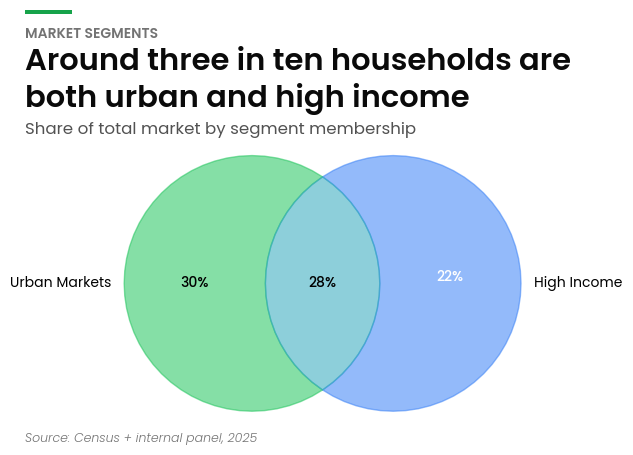

In [ ]:
# Urban markets vs High-income households.
market_data = pd.DataFrame(
    {
        "groups": [(1, 0), (0, 1), (1, 1), (0, 0)],
        "percent": [30, 22, 28, 20],
    },
)

venn.plot(
    market_data,
    labels=["Urban Markets", "High Income"],
    subset_label_formatter=lambda value: f"{value}%",
    eyebrow="Market segments",
    title="Around three in ten households are both urban and high income",
    subtitle="Share of total market by segment membership",
    source_text="Source: Census + internal panel, 2025",
)
plt.show()